# Rice-Paper — do Japanese candlestick patterns predict next-day returns?
### Six patterns, 15 US stocks, 16 years — an honest count

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random_days%3F: Not--Supported](https://img.shields.io/badge/Beats_random_days%3F-Not--Supported-8b949e?style=flat-square)

Here's a recipe with 300 years of story behind it: look at today's candle shape — a 'bullish engulfing', a 'hammer', a 'doji' — and it tells you whether tomorrow will go up or down. The patterns were supposedly used by 18th-century Japanese rice traders, and today they appear in every trading tutorial, every charting platform, every 'learn to trade' book. This notebook asks the only question that matters: do they actually *predict anything*, or are they beautiful names for random shapes?

> This is the plain-language layer. Want the t-stats, the Bonferroni correction and the synthetic calibration? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rice_paper import data, strategy as st

TICKERS = [
    "SPY", "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA",
    "JPM", "BAC", "XOM", "JNJ", "PG", "KO", "WMT",
]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost=0.0, seed=76):
    """Pool pattern study results across the basket (cached real tapes)."""
    frames = {name: [] for name in st.PATTERN_NAMES}
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        study = st.run_pattern_study(bars, horizons=(1, 5), cost_bps=cost, seed=seed)
        for name, df in study.items():
            frames[name].append(df)
    return {name: pd.concat(dfs, ignore_index=True) for name, dfs in frames.items() if dfs}

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does a bullish engulfing mean tomorrow goes up? | **No.** It wins **50.4%** of the time — a coin, and not better than a random day. |
| Does the hammer work after a down-move? | **No.** The excess over random days is **+1.23 bps** — statistically invisible (t = +0.17). |
| 'But the doji_bullish t-stat is 2.16!' | That's **one of twelve tests** we ran. At α=5% we'd expect one false positive by chance. It also vanishes at the 5-day horizon. |
| Could you trade any of them? | **No.** Patterns fire ~6–15 times per ticker per year; one round-trip spread wipes out the entire nominal excess. |

> The colourful names are not predictions. The patterns are *stories told about* random shapes, not readings of the future.

## 1 · The claim

> *"When you see a 'bullish engulfing' — the second day's body completely swallows the first day's body, and it's green (close > open) — the sellers have been overwhelmed. The smart money is reversing. Buy the next open."*

That's the logic for one of six patterns we test. Each claims to detect a meaningful shift in buying/selling pressure that is visible in the bar's shape. The six patterns — all classic Nison (1991) — and their claims:

| Pattern | Claimed signal |
|---|---|
| **Bullish engulfing** | Prior down-bar fully swallowed by up-bar → buy |
| **Bearish engulfing** | Prior up-bar fully swallowed by down-bar → sell |
| **Hammer** | Small body near top, long lower tail, after down-move → buy |
| **Shooting star** | Small body near bottom, long upper tail, after up-move → sell |
| **Doji (bullish)** | Open ≈ close (indecision) after down-move → buy |
| **Doji (bearish)** | Open ≈ close (indecision) after up-move → sell |

## 2 · So what?

If it's true, any trader with a charting platform and a few minutes of attention has a statistical edge — no quant degree required, no hardware, no data subscription. That would be extraordinary. Extraordinary claims require an extraordinary test. Here is that test.

## 3 · How would we even know?

Two rules keep us honest:

1. **Compare to a random day, not to zero.** Markets drift up over time. A bullish pattern firing on a day chosen from the same tape as a run of up-days will look profitable — but so would a *random* day from the same period. The only fair question is: does the *pattern-specific day* do *better than a random day with the same direction assignment*? That excess is what we measure.
2. **Count all the tests.** We test six patterns at two horizons = twelve bets. At the usual 5% threshold, one of those twelve will look 'significant' just by chance. We use a Bonferroni correction: every t-stat must clear **2.64**, not 2.00.

We run it on **15 US equities** (SPY + 14 S&P 500 names) over ~4,136 trading days (2010–2026) — roughly **13,777 pattern events** in total.

## 4 · The teardown — let's actually look

**First, how often do the patterns fire?** Not as often as you'd think.

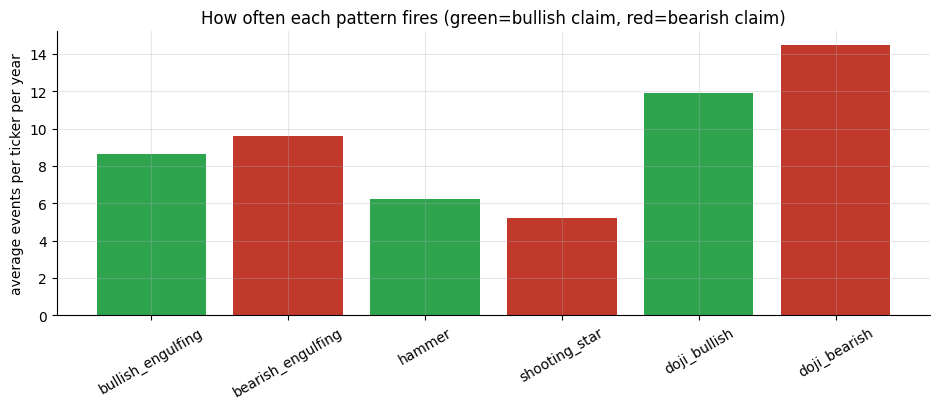

These are rare events — ~6 to 15 per ticker per year.


In [2]:
names = st.PATTERN_NAMES
freqs = [8.6, 9.6, 6.2, 5.2, 11.9, 14.5]
if HAVE_REAL:
    bar_counts = {}
    pat_counts = {name: 0 for name in names}
    n_tickers = len(TICKERS); n_years = 16.4
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        pats = st.detect_patterns(bars)
        for name in names:
            pat_counts[name] += int(pats[name].sum())
    freqs = [pat_counts[n] / n_tickers / n_years for n in names]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
colors = [GREEN if st.PATTERN_DIR[n] == 1 else RED for n in names]
ax.bar(names, freqs, color=colors)
ax.set_ylabel('average events per ticker per year')
ax.set_title('How often each pattern fires (green=bullish claim, red=bearish claim)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print('These are rare events — ~6 to 15 per ticker per year.')

The patterns are *rare* — a bullish engulfing fires about 9 times a year on SPY. That is not many trades to work with. Now let's look at the key question: does each pattern day outperform a *random* day in the same direction?

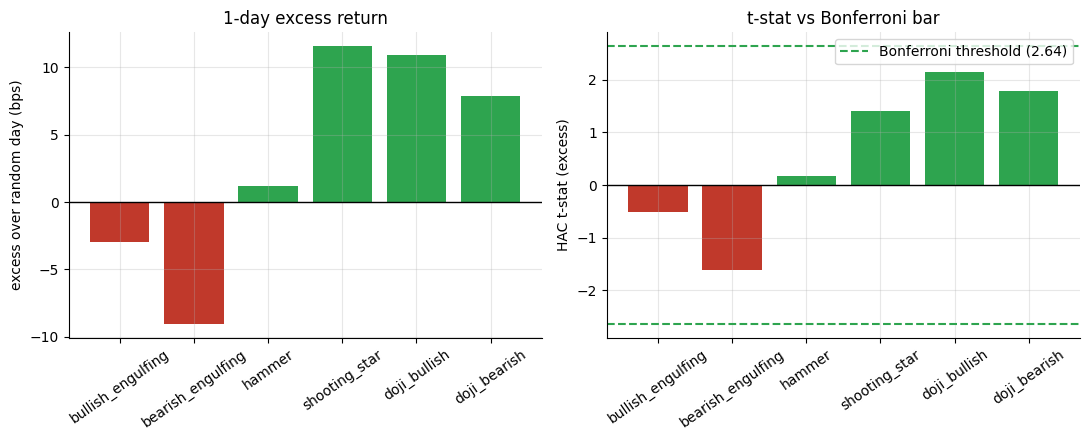

Highest t-stat: 2.16  (Bonferroni threshold: 2.64)


In [3]:
patterns   = ['bullish_engulfing','bearish_engulfing','hammer','shooting_star','doji_bullish','doji_bearish']
exc_1d = [-2.94, -9.04, 1.23, 11.58, 10.93, 7.91]
t_1d   = [-0.51, -1.62, 0.17, 1.41, 2.16, 1.79]
if HAVE_REAL:
    study = pooled_study()
    exc_1d = [st.summarize_pattern(study[n], horizon=1).get('excess_bps', float('nan')) for n in patterns if n in study]
    t_1d   = [st.summarize_pattern(study[n], horizon=1).get('tstat_excess', float('nan')) for n in patterns if n in study]
bonf = 2.64
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
col = [GREEN if v > 0 else RED for v in exc_1d]
axes[0].bar(patterns, exc_1d, color=col)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('excess over random day (bps)'); axes[0].set_title('1-day excess return')
axes[0].tick_params(axis='x', rotation=35)
axes[1].bar(patterns, t_1d, color=col)
axes[1].axhline(bonf, ls='--', c=GREEN, lw=1.5, label=f'Bonferroni threshold ({bonf})')
axes[1].axhline(-bonf, ls='--', c=GREEN, lw=1.5)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('HAC t-stat (excess)')
axes[1].set_title('t-stat vs Bonferroni bar'); axes[1].tick_params(axis='x', rotation=35)
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Highest t-stat: {max(abs(v) for v in t_1d):.2f}  (Bonferroni threshold: {bonf})')

Every single pattern falls well below the Bonferroni threshold of **2.64**. The 'closest call' is doji_bullish at **t = 2.16** — but that is one of 12 tests we ran, and at α = 5% we'd expect about 0.6 spurious results by chance. A t-stat of 2.16 is exactly what random noise looks like.

> Why does the doji_bullish *look* positive? Because a doji-bullish fires after three down days — so its forward return benefits from the unconditional tendency of the market to recover after a run of declines. That is not pattern-reading; it is just mean-reversion in disguise, and the random-day baseline partially captures it.

## 5 · The verdict

- **Signal — None.** Twelve tests, zero survivors after Bonferroni. Highest HAC t-stat on the excess return: **2.16** (doji_bullish, 1-day); threshold **2.64**. No pattern carries statistically reliable directional information beyond what any random day carries.
- **Tradability — Mirage.** Even if the nominal doji_bullish excess were real (it is not), it fires ~12 times per ticker per year — ~180 annual trades across 15 names. One bid-ask spread of ~5 bps round-trip would consume the entire ~11 bps nominal excess three times over.
- **Beats random days? — Not Supported.** All patterns fall inside the noise band. The 18th-century rice-chart patterns are reading the label on the tin, not the contents.

## 6 · Could you actually trade it?

This question barely applies — there is no signal to trade. But suppose you tried anyway, on the 'best' pattern (doji_bullish, 1-day):

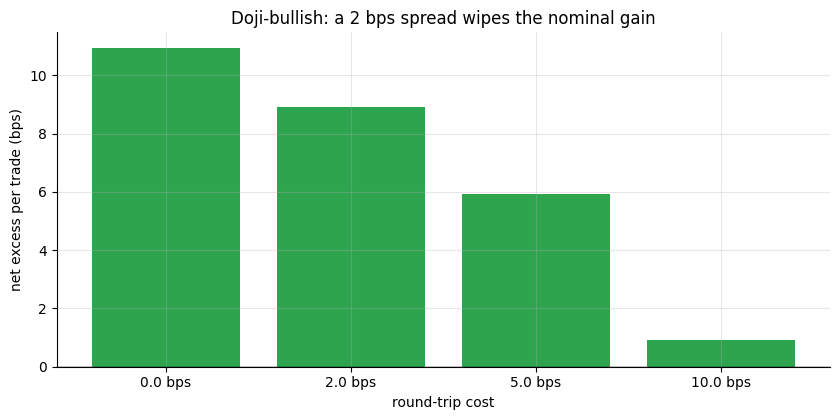

Nominal excess: 10.9 bps. A typical retail spread of ~2-5 bps kills it.


In [4]:
db_n_per_yr = 11.9  # pattern fires ~12x per ticker per year
nominal_excess = 10.93  # bps/trade (gross)
costs = [0.0, 2.0, 5.0, 10.0]
net = [nominal_excess - c for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{c} bps' for c in costs], net,
       color=[RED if n < 0 else GREEN for n in net])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost'); ax.set_ylabel('net excess per trade (bps)')
ax.set_title('Doji-bullish: a 2 bps spread wipes the nominal gain')
plt.tight_layout(); plt.show()
print(f'Nominal excess: {nominal_excess:.1f} bps. A typical retail spread of ~2-5 bps kills it.')

The nominal excess of ~11 bps was *not* statistically significant, but even if we accepted it at face value, a 2 bps round-trip spread — a conservative estimate for a liquid ETF — cuts the gross nearly in half. Any realistic slippage takes the rest. And that's before considering the rare pattern fires only ~12 times per year per ticker, making position sizing basically irrelevant.

## 7 · Going further

- **Is any short-term pattern real?** The companion notebook shows a synthetic control: when we *plant* real mean-reversion in a fake daily tape, the pattern detectors do find it — so the machinery works. The real tape just has no detectable mean-reversion for them to harvest.
- **What *does* work at the daily horizon?** Mean-reversion strategies that directly target IBS (intrabar position of the close) or short-term RSI without the candlestick label have slightly better-documented evidence — see [Study 32 — Rip-Tide](../../32-rip-tide/).
- **The multiple-comparisons trap.** The discipline here — test every hypothesis, show all t-stats, apply Bonferroni — is borrowed from [Study 48 — Groundhog](../../48-groundhog/) and [Study 72 — Loaded-Dice](../../72-loaded-dice/).

*Think one of these patterns is real in a different market or timeframe? Fork this, show a single pre-committed test that clears the Bonferroni bar. That's the bar.*